# Quick Recap
- Python libraries - NumPy, Pandas, Matplotlib, Statsmodels
- Simple Linear Regression

## Markdown or Text cells
Jupyter Notebook or Google Colab has markdown or text cells to write our summary notes which are compatible with LaTeX

Here are some basics of using LaTeX in text cells.

- We use `#` ahead of the text we are using as our heading. there are four levels of header available in Jupyter Notebook/Colab. For example
# Title
## Major Heading
### Sub Heading
#### Sub section heading

- To emphasize on some part of text we can write it in *italics* or in **bold**.

- We can write our mathematical symbols inside dollar sign for example $f(x)$ or $\alpha$

- We write the mathematical equation in a new line within dollar signs using the Latex format, for example
$f(x) = \frac{1}{a+b} x^{a/b}$

Refer to [Cheatsheet](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet) for further addition to the toolbox for managing markdown cells in Notebook/Colab.



# Regression Analysis
We will be using wooldridge datasets to learn and execute the python programs for regression analysis. The package 'wooldridge' allow us to directly import data from repository. Let's first install this package and import the essential libraries for regression analysis  

In [2]:
pip install wooldridge

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 38.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import wooldridge
import matplotlib.pyplot as plt

## Simple Linear Regression
We use regression analysis to study how a variable $y$ varies with changes in $x$. We can use a simple equation

$y = β_0 + \beta_1 x + u$

This defines the **simple linear regression model**. $y$ is referred as dependent variable and $x$ as explanatory variable. $u$ is called the error term or disturbance in relaionship.

For example, a model relating a person's wage to his education and other unobserved factors can be written as follows:

$wage = \beta_0 + \beta_1 educ + u$

If $wage$ is measured in dollars per hour and $educ$ in years of education, then $\beta_1$ measures the change in hourly wage given another year of education, holding other factors fixed.

We will be using `wage1` dataset from `wooldridge` which contains data for `526` indivduals on their hourly wages and their education.

In [ ]:
wage1 = wooldridge.dataWoo('wage1')
print(wage1.head())
wage1.tail()

We will use `statsmodels` package to estimate the coefficients using the given sample. The most common estimates are *ordinary least squares* which are obtained through minimizing the residuals. The OLS estimates are unbiased and effiecient under the **Gauss-Markov** assumptions.
- Linear in parameters
- Random sampling
- Sample variation in the explanatory variable
- Zero conditional mean $E(u|x) = 0$
- Homoskedasticity $Var(u|x) = \sigma^2$

For a detailed discussion on OLS and GM assumptions, please refer to [Wooldridge Econometrics](https://cbpbu.ac.in/userfiles/file/2020/STUDY_MAT/ECO/2.pdf) textbook.

In [ ]:
reg = smf.ols(formula='wage ~ educ', data=wage1)
results = reg.fit()
print(f'results.summary(): \n{results.summary()}\n')

results.summary(): 
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Sat, 26 Aug 2023   Prob (F-statistic):           2.78e-22
Time:                        04:08:08   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9049      0.685

We interpret the results in following way: the slope coefficient $\beta_1$ is obtained as `0.54` which implies that one more year of education increases hourly wage by $54$ cents an hour. The intercept of `-0.90` literally means that a person with no education has a predicted wage of -90 cents an hour, which is silly. If we look at the data, there are only 18 people with less than eight years of education. Consequently, the regression line does poorly at very low levels of education.

We look at the p-value `P>|t|` of estimated coefficient to determine their significance. If this value is less than 0.05, the estimated coefficient is said to be significant at 95% confidence level. For a detailed discussion on this please refer to [Wooldridge Econometrics](https://cbpbu.ac.in/userfiles/file/2020/STUDY_MAT/ECO/2.pdf) textbook.  

Another key component of the regression results is **R-squared** which is a measure of *goodness-of-fit*. R-squared valur of `0.165` means education explains 16.5% of the variation in the wages for this sample.

Let's have a look at the data.

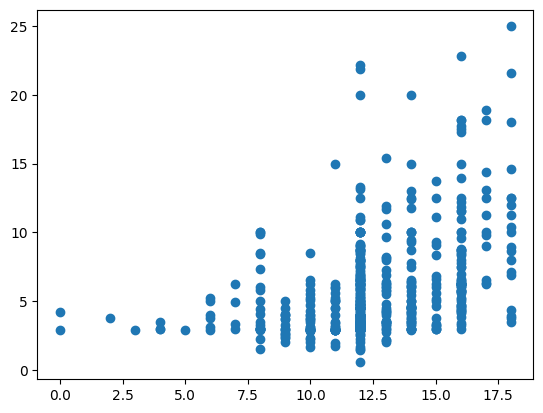

In [7]:
plt.scatter(x = wage1.educ, y = wage1.wage)

Looking at data provides a hint that a nonlinear relation between wage and education better fit in the sample. A a better characterization of how wage changes with education is that each year of education increases wage by a constant percentage.  A model that gives (approximately) a constant percentage effect is

$\log (wage) = \beta_0 + \beta_1 educ + u$

We can estimate this model in the following way

In [ ]:
reg = smf.ols(formula='np.log(wage) ~ educ', data=wage1)
results = reg.fit()
print(f'results.summary(): \n{results.summary()}\n')

results.summary(): 
                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     119.6
Date:                Sat, 26 Aug 2023   Prob (F-statistic):           3.27e-25
Time:                        04:10:02   Log-Likelihood:                -359.38
No. Observations:                 526   AIC:                             722.8
Df Residuals:                     524   BIC:                             731.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5838      0.097

We interpret the slope coefficient of `0.0827`: wage increases by 8.27% for every additional year of education. Other interpretation remains similar to above model.

## Multiple Regression Analysis
We have data available for experience and tenure as well. We intend to use that by including them in the regression equation as explanatory variables.

$\log (wage) = \beta_0 + \beta_1 educ  + \beta_2 exper + \beta_3 tenure + u $

Variables description:

wage - wages per hour (in dollars)

educ - years of education

exper - total years of experience

tenure - years with current employer

We can estimate this model using the following command

In [9]:
reg = smf.ols(formula='np.log(wage) ~ educ + exper + tenure', data=wage1)
results = reg.fit()
print(f'results.summary(): \n{results.summary()}\n')


results.summary(): 
                            OLS Regression Results                            
Dep. Variable:           np.log(wage)   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     80.39
Date:                Sat, 26 Aug 2023   Prob (F-statistic):           9.13e-43
Time:                        13:35:42   Log-Likelihood:                -313.55
No. Observations:                 526   AIC:                             635.1
Df Residuals:                     522   BIC:                             652.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2844      0.104

The estimates $\beta_1$, $\beta_2$ and $\beta_3$ have *partial effects* or *ceteris paribus* interpretations. For example, the coefficient `0.92` means that holding `exper` and `tenure` fixed, another year of education is predicted to increase `log(wage)` by 0.092, which translate into an approximate 9.2% increase in wage. We check the significance of estimates and goodnes-of-fit in the same fashion as in simple linear regression.

## Multicollinearity
- High correlation between two or more explanatory variables id called **multicollinearity**.
- We use Variance Inflation Factor (VIF) to detect multicollinearity.
- First regress the concerned variable $j$ with other explanatory variables.
- The VIF is computed as
$VIF_j = \frac{1}{1-R^2_j}$
- If VIF is more than 10, that is 90% of the variation is explained from covariates, we conclude that multicollinearity if a problem for estimating $\beta_j$, then variable $j$ is dropped from the explanatory variables.

We can using following commands to check multicollinearity manually and using statsmodels package, respectively.

In [11]:
# regressing explanatory variables for calculation of R2 & VIF:
reg_educ = smf.ols(formula='educ ~ exper + tenure', data=wage1)
reg_exper = smf.ols(formula='exper ~ educ + tenure', data=wage1)
reg_tenure = smf.ols(formula='tenure ~ educ + exper', data=wage1)
#results_hsGPA = reg_hsGPA.fit()
R2_educ = reg_educ.fit().rsquared
R2_exper = reg_exper.fit().rsquared
R2_tenure = reg_tenure.fit().rsquared
VIF_educ = 1 / (1 - R2_educ)
VIF_exper = 1 / (1 - R2_exper)
VIF_tenure = 1 / (1 - R2_tenure)
print(f'VIF_educ: {VIF_educ}\n')
print(f'VIF_exper: {VIF_exper}\n')
print(f'VIF_tenure: {VIF_tenure}\n')

VIF_educ: 1.1127707502838835

VIF_exper: 1.477617772631778

VIF_tenure: 1.3492955605611776



In [12]:
import statsmodels.stats.outliers_influence as smo
import patsy as pt
# extract matrices using patsy:
y, X = pt.dmatrices('np.log(wage) ~ educ + exper + tenure',
data=wage1, return_type='dataframe')
# get VIF:
K = X.shape[1]
VIF = np.empty(K)
for i in range(K):
  VIF[i] = smo.variance_inflation_factor(X.values, i)
print(f'VIF: \n{VIF}\n')

VIF: 
[29.37890286  1.11277075  1.47761777  1.34929556]



We conclude that the wage equation does not have the problem of multicollinearity.

## F-test
The F-test can be used in regression analysis to test the restriction in the model. For example, if we impose a restriction that the coefficient of tenure is zero. We interpret the F-test results: if the pval of the test is below 0.05, we reject the null hypothesis at 95% confidence level, that is the hypotheses formed or the restrictions imposed by us are not true for the sample.

In [17]:
# automated F test:
hypotheses = ['tenure = 0']
ftest = results.f_test(hypotheses)
fstat = ftest.statistic
fpval = ftest.pvalue
print(f'fstat: {fstat}\n')
print(f'fpval: {fpval}\n')


fstat: 50.88069315746461

fpval: 3.2944082401273636e-12



## Dummy Variables
We can have binary or calegorical varaibles in our regression model. For example, we can have a variable `female` which is 1 for females and 0 for males in our wage equation.

$\log (wage) = \beta_0 + \beta_1 female + \beta_2 educ  + \beta_3 exper + \beta_4 tenure + u $

If we take  woman and a man with the same levels of education, experience  and tenure, the woman earns, on average, 1.81 dollars less per hour than the man. We can conclude that the differtial of 1.81 dollars is due to gender or factors related to gender that we have not controlled for in the regression.

In [ ]:
wage1.head()

In [ ]:
reg = smf.ols(formula='wage ~ female + educ + exper + tenure', data=wage1)
results = reg.fit()
# print regression table:
table = pd.DataFrame({'b': round(results.params, 4),
                      'se': round(results.bse, 4),
                      't': round(results.tvalues, 4),
                      'pval': round(results.pvalues, 4)})
print(f'table: \n{table}\n')
# print(f'results.summary(): \n{results.summary()}\n')

table: 
                b      se        t    pval
Intercept -1.5679  0.7246  -2.1640  0.0309
female    -1.8109  0.2648  -6.8379  0.0000
educ       0.5715  0.0493  11.5836  0.0000
exper      0.0254  0.0116   2.1951  0.0286
tenure     0.1410  0.0212   6.6632  0.0000



The below commnd in the case of multiple dummy variables. `*` is used between two variables if we intend to use the interaction betwee them also in the regression analysis.

In [ ]:
reg = smf.ols(formula='np.log(wage) ~ married*female + educ + exper +I(exper**2) + tenure + I(tenure**2)', data=wage1)
results = reg.fit()
# print regression table:
table = pd.DataFrame({'b': round(results.params, 4),
                      'se': round(results.bse, 4),
                      't': round(results.tvalues, 4),
                      'pval': round(results.pvalues, 4)})
print(f'table: \n{table}\n')
# print(f'results.summary(): \n{results.summary()}\n')

table: 
                     b      se        t    pval
Intercept       0.3214  0.1000   3.2135  0.0014
married         0.2127  0.0554   3.8419  0.0001
female         -0.1104  0.0557  -1.9797  0.0483
married:female -0.3006  0.0718  -4.1885  0.0000
educ            0.0789  0.0067  11.7873  0.0000
exper           0.0268  0.0052   5.1118  0.0000
I(exper ** 2)  -0.0005  0.0001  -4.8471  0.0000
tenure          0.0291  0.0068   4.3016  0.0000
I(tenure ** 2) -0.0005  0.0002  -2.3056  0.0215



In [ ]:
import statsmodels.api as sm
# ANOVA table:
table_anova = sm.stats.anova_lm(results, typ=2)
print(f'table_anova: \n{table_anova}\n')

## Heteroskadasticity
Homoskedasticity fails whenever the variance of the unobservables changes across different segments of the population, where the segments are determined by different values of the explanatory variables.

Heteroskedasticity does not cause bias or inconsistency in the OLS estimators, but the usual standard errors and test statistics are no longer valid.

There are two popular ways to test for heteroskedasticity:
- Breusch Pagan test - regress the squared OLS residuals on explanatory variables
- White test - regress the squared OLS residuals on fitted and squared fitted values.

Below are commands to perform these tests using python. It provides the test statistic and pvalue for the null hypothesis of homoskedasticity.
In the linear model below the pvalue in the BP test is less than 0.05, we reject the null hypothesis of homoskedasticity. It means there is heteroskadascticity. Whereas in the model with `log`, the pvalue of the test statistic is above 0.05, we fail to reject null hypothesis, meaning the model is homoskedastic.

We use `hprice1` dataset to run a regression and test for heteroskedasticity. The vaiables are as follows:

price - house price.

lotsize - size of the lot, in feet.

sqrft - square footage.

bdrms - number of bedrooms.


In [ ]:
hprice1 = wooldridge.dataWoo('hprice1')
# estimate model:
reg = smf.ols(formula='price ~ lotsize + sqrft + bdrms', data=hprice1)
results = reg.fit()
table = pd.DataFrame({'b': round(results.params, 4),
                      'se': round(results.bse, 4),
                      't': round(results.tvalues, 4),
                      'pval': round(results.pvalues, 4)})
print(f'table: \n{table}\n')
# automatic BP test (LM version):
y, X = pt.dmatrices('price ~ lotsize + sqrft + bdrms', data=hprice1, return_type='dataframe')
result_bp_lm = sm.stats.diagnostic.het_breuschpagan(results.resid, X)
bp_lm_statistic = result_bp_lm[0]
bp_lm_pval = result_bp_lm[1]
print(f'bp_lm_statistic: {bp_lm_statistic}\n')
print(f'bp_lm_pval: {bp_lm_pval}\n')
# manual BP test (F version):
hprice1['resid_sq'] = results.resid ** 2
reg_resid = smf.ols(formula='resid_sq ~ lotsize + sqrft + bdrms', data=hprice1)
results_resid = reg_resid.fit()
bp_F_statistic = results_resid.fvalue
bp_F_pval = results_resid.f_pvalue
print(f'bp_F_statistic: {bp_F_statistic}\n')
print(f'bp_F_pval: {bp_F_pval}\n')


table: 
                 b       se       t    pval
Intercept -21.7703  29.4750 -0.7386  0.4622
lotsize     0.0021   0.0006  3.2201  0.0018
sqrft       0.1228   0.0132  9.2751  0.0000
bdrms      13.8525   9.0101  1.5374  0.1279

bp_lm_statistic: 14.092385504350183

bp_lm_pval: 0.0027820595556891643

bp_F_statistic: 5.338919363241395

bp_F_pval: 0.002047744420936124



In [ ]:
hprice1 = wooldridge.dataWoo('hprice1')
# estimate model:
reg = smf.ols(formula='np.log(price) ~ np.log(lotsize) + np.log(sqrft) + bdrms', data=hprice1)
results = reg.fit()
# BP test:
y, X_bp = pt.dmatrices('np.log(price) ~ np.log(lotsize) + np.log(sqrft) + bdrms', data=hprice1, return_type='dataframe')
result_bp = sm.stats.diagnostic.het_breuschpagan(results.resid, X_bp)
bp_statistic = result_bp[0]
bp_pval = result_bp[1]
print(f'bp_statistic: {bp_statistic}\n')
print(f'bp_pval: {bp_pval}\n')
# White test:
X_wh = pd.DataFrame({'const': 1, 'fitted_reg': results.fittedvalues,
'fitted_reg_sq': results.fittedvalues ** 2})
result_white = sm.stats.diagnostic.het_breuschpagan(results.resid, X_wh)
white_statistic = result_white[0]
white_pval = result_white[1]
print(f'white_statistic: {white_statistic}\n')
print(f'white_pval: {white_pval}\n')


bp_statistic: 4.223245741805276

bp_pval: 0.23834482631492962

white_statistic: 3.4472865468746834

white_pval: 0.17841494794136223



## Weighted Least Squares
In presence of heteroskedasticity, we use  *weighted least squares (WLS)* estimators. This name comes from the fact that we minimize the
weighted sum of squared residuals, where each squared residual is weighted by $1/h_i$, where $h_i$ is the function of explanatory variables that determines the heteroskedasticity. The idea is that less weight is given to observations with a higher error variance.

Below is an illustration of WLS estimation using dataset `401ksubs`.

Variables:

nettfa - net total financial wealth (in $1000s)

inc - income

e401k - indicator whwther individual eligible for pension plan

In [ ]:
k401ksubs = wooldridge.dataWoo('401ksubs')
# subsetting data:
k401ksubs_sub = k401ksubs[k401ksubs['fsize'] == 1]
# OLS (only for singles, i.e. 'fsize'==1):
reg_ols = smf.ols(formula='nettfa ~ inc + I((age-25)**2) + male + e401k', data=k401ksubs_sub)
results_ols = reg_ols.fit(cov_type='HC0')
# print regression table:
table_ols = pd.DataFrame({'b': round(results_ols.params, 4),
                          'se': round(results_ols.bse, 4),
                          't': round(results_ols.tvalues, 4),
                          'pval': round(results_ols.pvalues, 4)})
print(f'table_ols: \n{table_ols}\n')
# WLS:
wls_weight = list(1 / k401ksubs_sub['inc'])
reg_wls = smf.wls(formula='nettfa ~ inc + I((age-25)**2) + male + e401k', weights=wls_weight, data=k401ksubs_sub)
results_wls = reg_wls.fit()
# print regression table:
table_wls = pd.DataFrame({'b': round(results_wls.params, 4),
                          'se': round(results_wls.bse, 4),
                          't': round(results_wls.tvalues, 4),
                          'pval': round(results_wls.pvalues, 4)})
print(f'table_wls: \n{table_wls}\n')


table_ols: 
                          b      se       t    pval
Intercept          -20.9850  3.4909 -6.0114  0.0000
inc                  0.7706  0.0994  7.7486  0.0000
I((age - 25) ** 2)   0.0251  0.0043  5.7912  0.0000
male                 2.4779  2.0558  1.2053  0.2281
e401k                6.8862  2.2837  3.0153  0.0026

table_wls: 
                          b      se        t    pval
Intercept          -16.7025  1.9580  -8.5304  0.0000
inc                  0.7404  0.0643  11.5140  0.0000
I((age - 25) ** 2)   0.0175  0.0019   9.0796  0.0000
male                 1.8405  1.5636   1.1771  0.2393
e401k                5.1883  1.7034   3.0458  0.0024



In [ ]:
# robust results (Refined White SE):
results_white = reg_wls.fit(cov_type='HC3')
table_white = pd.DataFrame({'b': round(results_white.params, 4),
                            'se': round(results_white.bse, 4),
                            't': round(results_white.tvalues, 4),
                            'pval': round(results_white.pvalues, 4)})
print(f'table_white: \n{table_white}\n')

Following example uses feasible generalized least squares (FGLS) method with WLS to estimate valid eastimators. It use `smoke` data set which has data on number of cigerattes smoked per day (`cigs`), income, price of cigerattes (`cigpric`), education, age,  a binary indicator equal to unity if the person resides in a state with restaurant smoking restrictions (`restaurn`).

In [ ]:
smoke = wooldridge.dataWoo('smoke')
# OLS:
reg_ols = smf.ols(formula='cigs ~ np.log(income) + np.log(cigpric) +educ + age + I(age**2) + restaurn', data=smoke)
results_ols = reg_ols.fit()
table_ols = pd.DataFrame({'b': round(results_ols.params, 4),
                          'se': round(results_ols.bse, 4),
                          't': round(results_ols.tvalues, 4),
                          'pval': round(results_ols.pvalues, 4)})
print(f'table_ols: \n{table_ols}\n')
# BP test:
y, X = pt.dmatrices('cigs ~ np.log(income) + np.log(cigpric) + educ +age + I(age**2) + restaurn', data=smoke, return_type='dataframe')
result_bp = sm.stats.diagnostic.het_breuschpagan(results_ols.resid, X)
bp_statistic = result_bp[0]
bp_pval = result_bp[1]
print(f'bp_statistic: {bp_statistic}\n')
print(f'bp_pval: {bp_pval}\n')
# FGLS (estimation of the variance function):
smoke['logu2'] = np.log(results_ols.resid ** 2)
reg_fgls = smf.ols(formula='logu2 ~ np.log(income) + np.log(cigpric) +educ + age + I(age**2) + restaurn', data=smoke)
results_fgls = reg_fgls.fit()
table_fgls = pd.DataFrame({'b': round(results_fgls.params, 4),
                           'se': round(results_fgls.bse, 4),
                           't': round(results_fgls.tvalues, 4),
                           'pval': round(results_fgls.pvalues, 4)})
print(f'table_fgls: \n{table_fgls}\n')
# FGLS (WLS):
wls_weight = list(1 / np.exp(results_fgls.fittedvalues))
reg_wls = smf.wls(formula='cigs ~ np.log(income) + np.log(cigpric) +educ + age + I(age**2) + restaurn', weights=wls_weight, data=smoke)
results_wls = reg_wls.fit()
table_wls = pd.DataFrame({'b': round(results_wls.params, 4),
                          'se': round(results_wls.bse, 4),
                          't': round(results_wls.tvalues, 4),
                          'pval': round(results_wls.pvalues, 4)})
print(f'table_wls: \n{table_wls}\n')


table_ols: 
                      b       se       t    pval
Intercept       -3.6398  24.0787 -0.1512  0.8799
np.log(income)   0.8803   0.7278  1.2095  0.2268
np.log(cigpric) -0.7509   5.7733 -0.1301  0.8966
educ            -0.5015   0.1671 -3.0016  0.0028
age              0.7707   0.1601  4.8132  0.0000
I(age ** 2)     -0.0090   0.0017 -5.1765  0.0000
restaurn        -2.8251   1.1118 -2.5410  0.0112

bp_statistic: 32.25841908120121

bp_pval: 1.4557794830278942e-05

table_fgls: 
                      b      se        t    pval
Intercept       -1.9207  2.5630  -0.7494  0.4538
np.log(income)   0.2915  0.0775   3.7634  0.0002
np.log(cigpric)  0.1954  0.6145   0.3180  0.7506
educ            -0.0797  0.0178  -4.4817  0.0000
age              0.2040  0.0170  11.9693  0.0000
I(age ** 2)     -0.0024  0.0002 -12.8931  0.0000
restaurn        -0.6270  0.1183  -5.2982  0.0000

table_wls: 
                      b       se       t    pval
Intercept        5.6355  17.8031  0.3165  0.7517
np.log(income

## Endogeneity
 $E(e|x) \neq 0$

When conditional mean of erroe term is not zero. Endogeneity can arise ffrom multiple reasons.
- Omitted variable bias: When we miss an important variable which affect the explanatory variable, significantly. For exmple in our wage-education relation, we have an unobserved innate abiliy of individual that affect the education of individual. This is the case of ommited variables bias. In this case the OLS estimates are biased.
- Measurement error: When we cannot collect accurate data for some variable. For example, rainfall measure is taken from a point in specified area but actual rainfall may vary across the region.
- Reverse causality: When dependent and explanatory simultaneously affects each other. For example, in a relation between income and education, income affects education as well as education has an impact on income.

In the presence of endogeneity, the OLS estimates are no longer unbiased and efficient. We adopt new techniques such as *Instumental variables or 2SLS*.

## Instrumental Variables
We look out for another variable which is uncorrelated with the omitted variable (exogeneity) and it must be related to the endogeneous variable (relevance). For example, in the case of wage equation, a possible instrument for education is father's education. Father's education does not impact the innate ability which is omitted in the original equation. It is positively related to the education of individual. And it affects the wage through education of individual, not directly.

Once we have identified instrument, we use IV regression which provides us the causal relation between wage and education. Please refer to chapter 15 in the [textbook](https://cbpbu.ac.in/userfiles/file/2020/STUDY_MAT/ECO/2.pdf) for a detailed discussion. We can use following commands to run IV regression.


In [ ]:
pip install linearmodels

In [ ]:
import linearmodels.iv as iv

In [ ]:
mroz = wooldridge.dataWoo('mroz')
# restrict to non-missing wage observations:
mroz = mroz.dropna(subset=['lwage'])
# OLS automatically:
reg_ols = smf.ols(formula='np.log(wage) ~ educ', data=mroz)
results_ols = reg_ols.fit()
# print regression table:
table_ols = pd.DataFrame({'b': round(results_ols.params, 4),
                          'se': round(results_ols.bse, 4),
                          't': round(results_ols.tvalues, 4),
                          'pval': round(results_ols.pvalues, 4)})
print(f'table_ols: \n{table_ols}\n')
# IV automatically:
reg_iv = iv.IV2SLS.from_formula(formula='np.log(wage) ~ 1 + [educ ~ fatheduc]', data=mroz)
results_iv = reg_iv.fit(cov_type='unadjusted', debiased=True)
# print regression table:
table_iv = pd.DataFrame({'b': round(results_iv.params, 4),
                         'se': round(results_iv.std_errors, 4),
                         't': round(results_iv.tstats, 4),
                         'pval': round(results_iv.pvalues, 4)})
print(f'table_iv: \n{table_iv}\n')



In [ ]:
# 1st stage (reduced form):
reg_redf = smf.ols(formula='educ ~ fatheduc', data=mroz)
results_redf = reg_redf.fit()
mroz['educ_fitted'] = results_redf.fittedvalues
# print regression table:
table_redf = pd.DataFrame({'b': round(results_redf.params, 4),
                           'se': round(results_redf.bse, 4),
                           't': round(results_redf.tvalues, 4),
                           'pval': round(results_redf.pvalues, 4)})
print(f'table_redf: \n{table_redf}\n')
# 2nd stage:
reg_secstg = smf.ols(formula='np.log(wage) ~ educ_fitted', data=mroz)
results_secstg = reg_secstg.fit()
# print regression table:
table_secstg = pd.DataFrame({'b': round(results_secstg.params, 4),
                             'se': round(results_secstg.bse, 4),
                             't': round(results_secstg.tvalues, 4),
                             'pval': round(results_secstg.pvalues, 4)})
print(f'table_secstg: \n{table_secstg}\n')



## Logit and Probit Model
When our dependent variable is binary, we use logit or probit models to get an probabilistic prediction of the dependent variables. These topics are covered in Chapter 17 of the [textbook](https://cbpbu.ac.in/userfiles/file/2020/STUDY_MAT/ECO/2.pdf).

In [ ]:
mroz.head()

In [ ]:
mroz = wooldridge.dataWoo('mroz')
# estimate logit model:
reg_logit = smf.logit(formula='inlf ~ nwifeinc + educ + exper + I(exper**2) + age + kidslt6 + kidsge6', data=mroz)
# disp = 0 avoids printing out information during the estimation:
results_logit = reg_logit.fit(disp=0)
print(f'results_logit.summary(): \n{results_logit.summary()}\n')
# log likelihood value:
print(f'results_logit.llf: {results_logit.llf}\n')
# McFadden’s pseudo R2:
print(f'results_logit.prsquared: {results_logit.prsquared}\n')


In [ ]:
# estimate probit model:
reg_probit = smf.probit(formula='inlf ~ nwifeinc + educ + exper + I(exper**2) + age + kidslt6 + kidsge6', data=mroz)
# disp = 0 avoids printing out information during the estimation:
results_probit = reg_probit.fit(disp=0)
print(f'results_probit.summary(): \n{results_probit.summary()}\n')
# log likelihood value:
print(f'results_probit.llf: {results_probit.llf}\n')
# McFadden’s pseudo R2:
print(f'results_probit.prsquared: {results_probit.prsquared}\n')

## Time Series Analysis

We use `barium` data from wooldridge to perform data time series analysis.

Variables:

chnimp: volume of barium cloride imports from china

chempi: index of chemical production

gas: volume of gasoline production

rtwex: exchange rate index

ohers: indicators for filling status and months



In [ ]:
import matplotlib.pyplot as plt
barium = wooldridge.dataWoo('barium')
T = len(barium)
# monthly time series starting Feb. 1978:
barium.index = pd.date_range(start='1978-02', periods=T, freq='M')
print(f'barium["chnimp"].head(): \n{barium["chnimp"].head()}\n')
# plot chnimp (default: index on the x-axis):
plt.plot('chnimp', data=barium, color='black', linestyle='-')
plt.ylabel('chnimp')
plt.xlabel('time')
#plt.savefig('PyGraphs/Example-Barium.pdf')

In [ ]:
barium.head()

### Trend
Many economic time series have a common tendency of growing over time. We must recognize that some series contain a time trend in order to draw causal inference using time series data. For that purpose, we include time as a explanatory varibale in the regression model. An example is provided below:

In [ ]:
# linear regression with trend:
reg = smf.ols(formula='np.log(chnimp) ~ np.log(chempi) + np.log(gas) +np.log(rtwex) + befile6 + affile6 + afdec6 + t', data=barium)
results = reg.fit()
# print regression table:
table = pd.DataFrame({'b': round(results.params, 4),
                      'se': round(results.bse, 4),
                      't': round(results.tvalues, 4),
                      'pval': round(results.pvalues, 4)})
print(f'table: \n{table}\n')

table: 
                     b       se       t    pval
Intercept      -2.3673  20.7822 -0.1139  0.9095
np.log(chempi) -0.6862   1.2397 -0.5535  0.5809
np.log(gas)     0.4657   0.8762  0.5315  0.5960
np.log(rtwex)   0.0782   0.4724  0.1656  0.8688
befile6         0.0905   0.2513  0.3600  0.7194
affile6         0.0970   0.2573  0.3770  0.7068
afdec6         -0.3515   0.2825 -1.2441  0.2158
t               0.0127   0.0038  3.3051  0.0012



### Seasonality
If a time series is observed at monthly or quarterly intervals (or even weekly or daily), it may exhibit seasonality. For example, it could be that the months just before the suit was filed are months where imports are higher or lower, on average, than in other months. We add dummay variable for each month to rule out the seasonal impact coming in different month and establish a more accurate relation between the dependent and explanatory variables.

In [ ]:
# linear regression with seasonal effects:
reg = smf.ols(formula='np.log(chnimp) ~ np.log(chempi) + np.log(gas) +np.log(rtwex) + befile6 + affile6 + afdec6 +'
'feb + mar + apr + may + jun + jul +aug + sep + oct + nov + dec', data=barium)
results = reg.fit()
# print regression table:
table = pd.DataFrame({'b': round(results.params, 4),
                      'se': round(results.bse, 4),
                      't': round(results.tvalues, 4),
                      'pval': round(results.pvalues, 4)})
print(f'table: \n{table}\n')

### Serial Autocorrelation
When present error terms are correlated with lagged values of the error terms i.e. $E(u_t|u_{t-1}) \neq 0$

This causes the usual OLS standard errors and statistics to be misleading.

We use Breusch-Godfrey or Durbin-Watson tests to check for autocorrelation (commands given below).

In [ ]:
reg = smf.ols(formula='np.log(chnimp) ~ np.log(chempi) + np.log(gas) +np.log(rtwex) + befile6 + affile6 + afdec6', data=barium)
results = reg.fit()
# automatic test:
bg_result = sm.stats.diagnostic.acorr_breusch_godfrey(results, nlags=3)
fstat_auto = bg_result[2]
fpval_auto = bg_result[3]
print(f'fstat_auto: {fstat_auto}\n')
print(f'fpval_auto: {fpval_auto}\n')

fstat_auto: 5.124662239772472

fpval_auto: 0.0022637197671316776



In [ ]:
# DW tests:
DW = sm.stats.stattools.durbin_watson(results.resid)
print(f'DW_s: {DW}\n')

DW_s: 1.4584144308481404



In [ ]:
phillips = wooldridge.dataWoo('phillips')
T = len(phillips)
# define yearly time series beginning in 1948:
date_range = pd.date_range(start='1948', periods=T, freq='Y')
phillips.index = date_range.year
# estimation of both Phillips curve models:
yt96 = (phillips['year'] <= 1996)
phillips['inf_diff1'] = phillips['inf'].diff()
reg_s = smf.ols(formula='Q("inf") ~ unem', data=phillips, subset=yt96)
reg_ea = smf.ols(formula='inf_diff1 ~ unem', data=phillips, subset=yt96)
results_s = reg_s.fit()
results_ea = reg_ea.fit()
# BG tests:
bg_s = sm.stats.diagnostic.acorr_breusch_godfrey(results_s, nlags=1)
bg_ea = sm.stats.diagnostic.acorr_breusch_godfrey(results_ea, nlags=1)
print(f'bg_s_fstat: {bg_s[2]}\n')
print(f'bg_s_fpval: {bg_s[3]}\n')
print(f'bg_ea_fstat: {bg_ea[2]}\n')
print(f'bg_ea_fpval: {bg_ea[3]}\n')
# DW tests:
DW_s = sm.stats.stattools.durbin_watson(results_s.resid)
DW_ea = sm.stats.stattools.durbin_watson(results_ea.resid)
print(f'DW_s: {DW_s}\n')
print(f'DW_ea: {DW_ea}\n')

## Yahoo Finance data imports for analysis
The below commands enable us to import data from yahoo finance for listed stocks. We can use this data for further time series analysis.

In [ ]:
import yfinance as yf
import pandas_datareader as pdr
import matplotlib.pyplot as plt
# download data for ’F’ (= Ford Motor Company) and define start and end:
yf.pdr_override()
tickers = ['F']
start_date = '2014-01-01'
end_date = '2022-12-31'
# use pandas_datareader for the import:
F_data = pdr.data.get_data_yahoo(tickers, start_date, end_date)
# look at imported data:
print(f'F_data.head(): \n{F_data.head()}\n')
print(f'F_data.tail(): \n{F_data.tail()}\n')
# time series plot of adjusted closing prices:
plt.plot('Close', data=F_data, color='black', linestyle='-')
plt.ylabel('Ford Close Price')
plt.xlabel('time')

For an example, below is the code to test for efficient market hypothesis.

In [ ]:
# calculate return as the log difference:
F_data['ret'] = np.log(F_data['Adj Close']).diff()
# time series plot of adjusted closing prices:
plt.plot('ret', data=F_data, color='black', linestyle='-')
plt.ylabel('FORD Log Returns')
plt.xlabel('time')
#plt.savefig(’PyGraphs/Example-EffMkts.pdf’)
# linear regression of models with lags:
F_data['ret_lag1'] = F_data['ret'].shift(1)
F_data['ret_lag2'] = F_data['ret'].shift(2)
F_data['ret_lag3'] = F_data['ret'].shift(3)
reg1 = smf.ols(formula='ret ~ ret_lag1', data=F_data)
reg2 = smf.ols(formula='ret ~ ret_lag1 + ret_lag2', data=F_data)
reg3 = smf.ols(formula='ret ~ ret_lag1 + ret_lag2 + ret_lag3', data=F_data)
results1 = reg1.fit()
results2 = reg2.fit()
results3 = reg3.fit()
# print regression tables:
table1 = pd.DataFrame({'b': round(results1.params, 4),
                       'se': round(results1.bse, 4),
                       't': round(results1.tvalues, 4),
                       'pval': round(results1.pvalues, 4)})
print(f'table1: \n{table1}\n')
table2 = pd.DataFrame({'b': round(results2.params, 4),
                       'se': round(results2.bse, 4),
                       't': round(results2.tvalues, 4),
                       'pval': round(results2.pvalues, 4)})
print(f'table2: \n{table2}\n')
table3 = pd.DataFrame({'b': round(results3.params, 4),
                       'se': round(results3.bse, 4),
                       't': round(results3.tvalues, 4),
                       'pval': round(results3.pvalues, 4)})
print(f'table3: \n{table3}\n')